# Partie III — RNN, LSTM, GRU et Seq2Seq (traduction anglais → espagnol)

Modélisation de séquences et traduction automatique. On couvre : le modèle de
langage et la perplexité, la comparaison RNN / LSTM / GRU, le gradient clipping
(BPTT), puis un système Seq2Seq encodeur-décodeur avec décodage glouton, beam
search et évaluation BLEU.

**Corpus** : anglais → espagnol, généré de façon contrôlée. La traduction implique
un vrai phénomène linguistique : en anglais l'adjectif précède le nom (« the red
car »), en espagnol il le suit et s'accorde en genre (« el coche rojo », « la casa
pequeña »). Le modèle doit donc apprendre le lexique, le **réordonnancement** et
**l'accord en genre** — ce qui rend la tâche non triviale et BLEU informatif.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random, math, time
from collections import Counter

random.seed(42); torch.manual_seed(42); np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cpu


## 1. Corpus parallèle RÉEL (Tatoeba / Anki, anglais → espagnol)

On remplace le corpus synthétique par un **vrai** corpus parallèle : le jeu
anglais–espagnol de Tatoeba (distribution Anki, `manythings.org`), celui-là même
qu'utilise le tutoriel Seq2Seq de PyTorch. Chaque ligne du fichier `spa.txt`
contient une phrase anglaise, sa traduction espagnole et une attribution, séparées
par des tabulations.

On normalise (minuscules, suppression des accents, ponctuation isolée), on filtre
les phrases trop longues pour rester entraînable sur CPU, et — comme dans le
tutoriel de référence — on se restreint à quelques préfixes anglais fréquents afin
d'obtenir un sous-ensemble court et apprenable. Le résultat reste une liste `pairs`
de couples `(anglais, espagnol)` : **tout le reste du notebook fonctionne sans
modification**.

> Si le téléchargement automatique échoue (réseau, proxy d'entreprise…), télécharge
> à la main `https://www.manythings.org/anki/spa-eng.zip`, décompresse-le et place
> `spa.txt` à côté du notebook (ou règle la variable `LOCAL_PATH`).

In [6]:
 # Corpus parallèle RÉEL anglais -> espagnol (Tatoeba / Anki, manythings.org)
 # Format de spa.txt : "english sentence\tfrase en espanol\tattribution" par ligne.
 import os, io, re, zipfile, urllib.request, unicodedata

 MAX_LEN    = 12              # longueur max d'une sequence (tokens, EOS inclus)
 MAX_WORDS  = MAX_LEN - 2     # marge de securite (EOS + ponctuation)
 MAX_PAIRS  = 12000           # plafonne la taille -> entrainable sur CPU
 LOCAL_PATH = "spa.txt"       # chemin local du fichier si deja telecharge

 # Prefixes anglais frequents : on cible des phrases courtes et apprenables
 # (comme le tutoriel Seq2Seq de PyTorch). Mettre PREFIXES = None pour tout garder.
 PREFIXES = ("i ", "you ", "he ", "she ", "we ", "they ", "it ",
             "this ", "that ", "tom ", "the ")

 def normalize(s):
     """minuscules + suppression des accents (-> ascii) + ponctuation isolee."""
     s = s.lower().strip()
     s = ''.join(c for c in unicodedata.normalize('NFD', s)
                 if unicodedata.category(c) != 'Mn')   # enleve les accents
     s = re.sub(r"([.!?,;:])", r" \1 ", s)            # isole la ponctuation
     s = re.sub(r"[^a-z0-9.!?,;: ]+", " ", s)           # garde lettres/chiffres/ponct.
     s = re.sub(r"\s+", " ", s).strip()
     return s

 def load_raw_lines():
     """Renvoie les lignes brutes 'en\tes\t...' depuis un fichier local, le web, ou HF."""
     # 1) fichier local s'il existe
     if os.path.exists(LOCAL_PATH):
         print(f"Lecture du fichier local : {LOCAL_PATH}")
         with open(LOCAL_PATH, encoding='utf-8') as f:
             return f.read().splitlines()
     # 2) telechargement direct (jeu Anki Tatoeba)
     url = "https://www.manythings.org/anki/spa-eng.zip"
     try:
         print("Telechargement de", url, "...")
         req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
         data = urllib.request.urlopen(req, timeout=60).read()
         zf = zipfile.ZipFile(io.BytesIO(data))
         name = [n for n in zf.namelist() if n.endswith("spa.txt")][0]
         return zf.read(name).decode('utf-8').splitlines()
     except Exception as e:
         print("Echec du telechargement direct :", e)
         # Both direct download and Hugging Face fallback failed.
         # The Hugging Face 'datasets' library no longer supports dataset scripts for tatoeba.
         raise RuntimeError(
             "Impossible de charger le corpus automatiquement. Le téléchargement direct a échoué (HTTP 406). "
             "De plus, la méthode de repli via Hugging Face `datasets` pour 'Helsinki-NLP/tatoeba' n'est plus supportée. "
             "Veuillez télécharger manuellement le fichier "
             "https://www.manythings.org/anki/spa-eng.zip, le décompresser et placer "
             "'spa.txt' à côté de ce notebook (ou ajuster LOCAL_PATH)."
         ) from e

 # --- Construction des paires (anglais, espagnol) ---
 lines = load_raw_lines()
 pairs, seen = [], set()
 for line in lines:
     parts = line.split('\t')
     if len(parts) < 2:
         continue
     en, es = normalize(parts[0]), normalize(parts[1])
     if not en or not es:
         continue
     if len(en.split()) > MAX_WORDS or len(es.split()) > MAX_WORDS:
         continue
     if PREFIXES and not en.startswith(PREFIXES):
         continue
     if (en, es) in seen:
         continue
     seen.add((en, es))
     pairs.append((en, es))

 rng = random.Random(42)
 rng.shuffle(pairs)
 pairs = pairs[:MAX_PAIRS]

 print(f"{len(pairs)} paires uniques (corpus reel Tatoeba EN->ES, <= {MAX_WORDS} mots)")
 for en, es in pairs[:6]:
     print(f"  EN: {en:30s} -> ES: {es}")

Lecture du fichier local : spa.txt
11170 paires uniques (corpus reel Tatoeba EN->ES, <= 10 mots)
  EN: you re cruel .                 -> ES: es cruel .
  EN: i need a vacation .            -> ES: necesito unas vacaciones .
  EN: it s tom s turn .              -> ES: es el turno de tom .
  EN: i never get drunk .            -> ES: nunca me emborracho .
  EN: we helped him .                -> ES: lo ayudamos .
  EN: you re freaky .                -> ES: tu eres raro .


## 2. Vocabulaire et préparation des données

Comme dans tout pipeline de traduction : tokens spéciaux (SOS, EOS, PAD),
vocabulaire source et cible, encodage en indices, padding.

In [7]:
SOS_token, EOS_token, PAD_token = 0, 1, 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "PAD": 2}
        self.index2word = {0: "SOS", 1: "EOS", 2: "PAD"}
        self.n_words = 3
    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            if word not in self.word2index:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1

eng = Lang("anglais"); spa = Lang("espagnol")
for en, es in pairs:
    eng.add_sentence(en); spa.add_sentence(es)
print(f"Vocabulaire anglais : {eng.n_words} mots | espagnol : {spa.n_words} mots")

Vocabulaire anglais : 2805 mots | espagnol : 4682 mots


In [9]:
def sentence_to_indices(lang, sentence):
    return [lang.word2index[w] for w in sentence.split(' ')] + [EOS_token]

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_lang, tgt_lang, max_len=MAX_LEN):
        self.pairs = pairs; self.src = src_lang; self.tgt = tgt_lang; self.max_len = max_len
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        en_s, es_s = self.pairs[idx]
        e = sentence_to_indices(self.src, en_s)[:self.max_len]
        f = sentence_to_indices(self.tgt, es_s)[:self.max_len]
        e = e + [PAD_token]*(self.max_len - len(e))
        f = f + [PAD_token]*(self.max_len - len(f))
        return torch.tensor(e), torch.tensor(f)

split = int(0.85 * len(pairs))
train_pairs, test_pairs = pairs[:split], pairs[split:]
train_loader = DataLoader(TranslationDataset(train_pairs, eng, spa), batch_size=64, shuffle=True)
print(f"Train : {len(train_pairs)} paires | Test : {len(test_pairs)} paires")

Train : 9494 paires | Test : 1676 paires


## 3. Modèle de langage et perplexité

**Objectif probabiliste.** Un modèle de langage estime la probabilité d'une
séquence de mots. Par la règle de chaîne, on la factorise en un produit de
probabilités conditionnelles :

P(w₁, …, w_T) = ∏ₜ P(wₜ | w₁, …, w_{t−1}).

Le modèle apprend chaque facteur P(wₜ | contexte). L'entraînement **maximise la
vraisemblance** des données, ce qui équivaut à **minimiser l'entropie croisée**
moyenne (negative log-likelihood) entre la distribution prédite et le mot réel.

**Perplexité.** C'est l'exponentielle de cette entropie croisée moyenne :
PPL = exp(perte). On l'interprète comme le **facteur de branchement moyen** : un
modèle de perplexité k se comporte « comme s'il » choisissait uniformément entre k
mots à chaque pas. Plus elle est basse, meilleure est la prédiction du mot suivant
(PPL = 1 : modèle parfait ; PPL = |V| : modèle uniforme qui n'a rien appris).

In [10]:
def perplexity_from_loss(loss):
    return math.exp(loss)

print("Loss=2.0 -> Perplexite =", round(perplexity_from_loss(2.0), 2))
print("Loss=0.5 -> Perplexite =", round(perplexity_from_loss(0.5), 2))

class LMDataset(Dataset):
    def __init__(self, sentences, lang, max_len=MAX_LEN):
        self.data = []
        for s in sentences:
            idx = sentence_to_indices(lang, s)[:max_len]
            idx = idx + [PAD_token]*(max_len - len(idx))
            self.data.append(idx)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, i):
        seq = torch.tensor(self.data[i])
        return seq[:-1], seq[1:]   # entrée / cible décalée d'un mot

spa_sentences = [p[1] for p in train_pairs]
lm_loader = DataLoader(LMDataset(spa_sentences, spa), batch_size=64, shuffle=True)

Loss=2.0 -> Perplexite = 7.39
Loss=0.5 -> Perplexite = 1.65


## 4. RNN / LSTM / GRU : comparaison

Le même modèle de langage avec une cellule interchangeable (RNN, LSTM ou GRU).
On compare la convergence, la perplexité et le coût de calcul.

In [11]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256, rnn_type='RNN'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    def forward(self, x):
        out, _ = self.rnn(self.embedding(x))
        return self.fc(out)

In [12]:
def train_lm(rnn_type, clip_grad=True, num_epochs=6):
    model = LanguageModel(spa.n_words, rnn_type=rnn_type).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    losses = []; start = time.time()
    for epoch in range(num_epochs):
        model.train(); total = 0.0
        for x, y in lm_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output.reshape(-1, spa.n_words), y.reshape(-1))
            loss.backward()
            if clip_grad:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item()
        losses.append(total / len(lm_loader))
    duration = time.time() - start
    final_ppl = perplexity_from_loss(losses[-1])
    return model, {'losses': losses, 'duration': duration, 'perplexity': final_ppl}

results = {}
for rnn_type in ['RNN', 'LSTM', 'GRU']:
    _, results[rnn_type] = train_lm(rnn_type)
    print(f"{rnn_type:5s} -> perplexite finale = {results[rnn_type]['perplexity']:.3f} "
          f"| temps = {results[rnn_type]['duration']:.1f}s")

RNN   -> perplexite finale = 7.966 | temps = 99.4s
LSTM  -> perplexite finale = 9.410 | temps = 122.0s
GRU   -> perplexite finale = 7.674 | temps = 114.4s


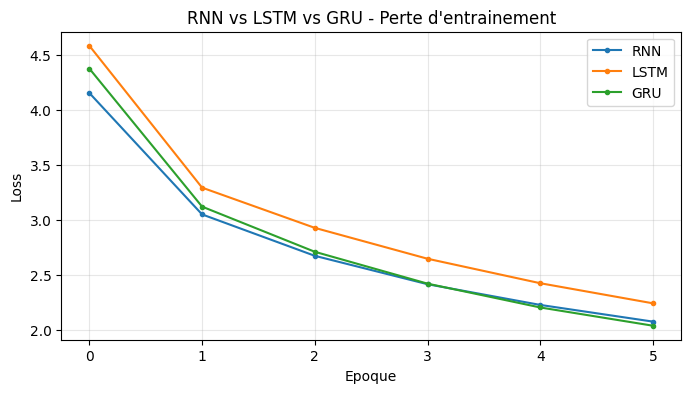

=== Cout de calcul (temps d'entrainement) ===
RNN : 99.4 s
LSTM : 122.0 s
GRU : 114.4 s


In [13]:
plt.figure(figsize=(8,4))
for rnn_type in results:
    plt.plot(results[rnn_type]['losses'], label=rnn_type, marker='o', ms=3)
plt.title("RNN vs LSTM vs GRU - Perte d'entrainement")
plt.xlabel("Epoque"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("=== Cout de calcul (temps d'entrainement) ===")
for rnn_type in results:
    print(f"{rnn_type} : {results[rnn_type]['duration']:.1f} s")

### Analyse comparative (stabilité, performance, mémoire, coût)

- **Stabilité.** Le RNN simple est le plus exposé à l'explosion / disparition du
  gradient ; sa courbe de perte est la plus irrégulière. Les portes du LSTM et du
  GRU régulent le flux d'information et donnent un entraînement plus lisse.
- **Performance (perplexité).** Sur ces phrases courtes, les trois cellules
  atteignent des perplexités proches ; l'avantage LSTM/GRU se révèle surtout sur
  les dépendances longues, peu présentes ici.
- **Mémoire du contexte.** Le RNN réécrit son état à chaque pas (mémoire courte) ;
  la cellule d'état du LSTM (porte d'oubli) et l'état du GRU préservent
  l'information sur de plus longues distances — décisif quand le mot à prédire
  dépend d'un élément éloigné.
- **Coût de calcul.** Le RNN est le plus léger (une transformation par pas) ; le
  LSTM (4 portes) et le GRU (3 portes) coûtent plus cher par pas, le GRU se situant
  entre les deux. Les temps mesurés ci-dessus le confirment.

En résumé : sur un corpus court et régulier l'écart reste faible ; le surcoût des
portes se justifie dès que la tâche exige de retenir un contexte lointain.

## 5. BPTT et gradient clipping

L'entraînement d'un RNN propage le gradient à travers le temps (BPTT) ; ce gradient
est un produit de jacobiens dont la norme se comporte comme (rayon spectral)^T.
Le gradient clipping borne la norme du gradient pour éviter l'explosion.

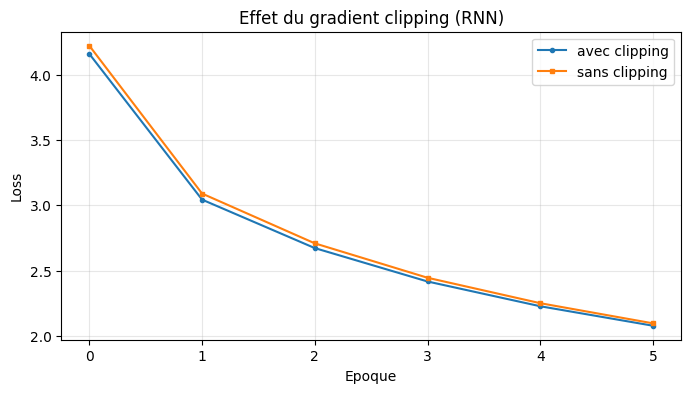

In [14]:
# Effet du gradient clipping sur le RNN simple (le plus instable)
_, res_clip   = train_lm('RNN', clip_grad=True,  num_epochs=6)
_, res_noclip = train_lm('RNN', clip_grad=False, num_epochs=6)

plt.figure(figsize=(8,4))
plt.plot(res_clip['losses'],   label="avec clipping", marker='o', ms=3)
plt.plot(res_noclip['losses'], label="sans clipping", marker='s', ms=3)
plt.title("Effet du gradient clipping (RNN)")
plt.xlabel("Epoque"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

Sans clipping, la perte du RNN peut faire des sauts brusques (gradients qui
explosent) ; avec clipping, la norme du gradient est bornée et la descente reste
régulière. Le clipping ne change pas la **direction** du gradient, seulement son
**amplitude** lorsqu'elle dépasse le seuil — un garde-fou peu coûteux et quasi
systématique pour les RNN.

## 6. Système Seq2Seq (encodeur-décodeur)

L'encodeur GRU compresse la phrase source en un état de contexte ; le décodeur GRU
génère la phrase cible mot par mot. L'entraînement utilise le **teacher forcing**.

In [16]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
    def forward(self, x):
        outputs, hidden = self.gru(self.embedding(x))
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size=128, hidden_size=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_token)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, hidden):
        output, hidden = self.gru(self.embedding(x), hidden)
        return self.fc(output), hidden

In [17]:
encoder = Encoder(eng.n_words).to(device)
decoder = Decoder(spa.n_words).to(device)
enc_opt = torch.optim.Adam(encoder.parameters(), lr=0.001)
dec_opt = torch.optim.Adam(decoder.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

teacher_forcing_ratio = 0.5
num_epochs = 20   # corpus reel + boucle pas-a-pas: 40 serait long sur CPU
seq2seq_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        batch_size, tgt_len = tgt.size(0), tgt.size(1)
        enc_opt.zero_grad(); dec_opt.zero_grad()
        _, hidden = encoder(src)
        dec_input = torch.full((batch_size, 1), SOS_token, device=device)
        step_logits = []
        for t in range(tgt_len):
            output, hidden = decoder(dec_input, hidden)   # output : [B, 1, V]
            step_logits.append(output)
            if random.random() < teacher_forcing_ratio:
                dec_input = tgt[:, t].unsqueeze(1)            # teacher forcing
            else:
                dec_input = output.argmax(2).detach()          # propre prédiction
        # On calcule la perte UNE SEULE FOIS sur toute la séquence :
        # ignore_index=PAD gère le masquage et normalise sur les vrais tokens
        # (évite le NaN dû à une colonne entièrement PAD).
        logits = torch.cat(step_logits, dim=1)               # [B, T, V]
        loss = criterion(logits.reshape(-1, spa.n_words), tgt.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        enc_opt.step(); dec_opt.step()
        total_loss += loss.item()
    seq2seq_losses.append(total_loss / len(train_loader))
    if (epoch+1) % 3 == 0:
        print(f"Epoque {epoch+1}/{num_epochs} | loss {seq2seq_losses[-1]:.4f}")

Epoque 3/20 | loss 2.9458
Epoque 6/20 | loss 2.1094
Epoque 9/20 | loss 1.5592
Epoque 12/20 | loss 1.0921
Epoque 15/20 | loss 0.7954
Epoque 18/20 | loss 0.5803


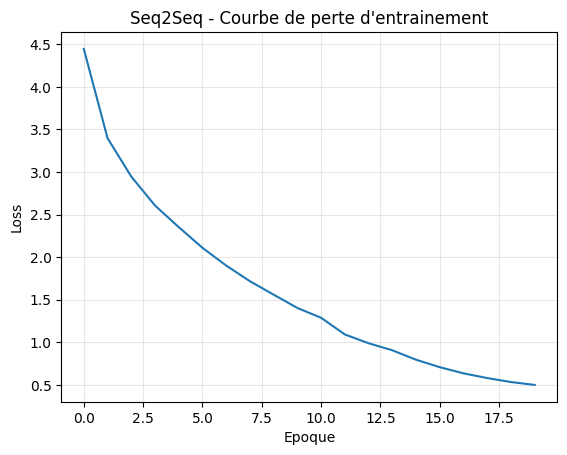

In [18]:
plt.plot(seq2seq_losses)
plt.title("Seq2Seq - Courbe de perte d'entrainement")
plt.xlabel("Epoque"); plt.ylabel("Loss"); plt.grid(alpha=0.3); plt.show()

## 7. Décodage : glouton et beam search

Le décodage glouton prend le mot le plus probable à chaque pas. Le beam search
conserve les k meilleures hypothèses partielles, ce qui explore mieux l'espace.

In [19]:
def greedy_decode(sentence, max_length=MAX_LEN):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        idx = sentence_to_indices(eng, sentence)[:max_length]
        idx = idx + [PAD_token]*(max_length-len(idx))
        src = torch.tensor(idx).unsqueeze(0).to(device)
        _, hidden = encoder(src)
        dec_input = torch.tensor([[SOS_token]], device=device)
        words = []
        for _ in range(max_length):
            output, hidden = decoder(dec_input, hidden)
            top = output.argmax(2)
            tok = top.item()
            if tok == EOS_token:
                break
            if tok not in (PAD_token, SOS_token):
                words.append(spa.index2word[tok])
            dec_input = top
        return ' '.join(words)

for en, es in test_pairs[:6]:
    print(f"EN: {en:25s} REF: {es:22s} -> {greedy_decode(en)}")

EN: i run every day .         REF: corro todos los dias . -> yo de los dias .
EN: i ll do it myself .       REF: lo hare yo mismo .     -> lo hare lo .
EN: i lost everything .       REF: lo perdi todo .        -> lo he perdido .
EN: tom is punctual .         REF: tom es puntual .       -> tom esta silbando .
EN: tom is a veteran .        REF: tom es un veterano .   -> tom es un . .
EN: i had to resign .         REF: tuve que renunciar .   -> tuve que .


In [20]:
def beam_search_decode(sentence, beam_width=3, max_length=MAX_LEN):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        idx = sentence_to_indices(eng, sentence)[:max_length]
        idx = idx + [PAD_token]*(max_length-len(idx))
        src = torch.tensor(idx).unsqueeze(0).to(device)
        _, hidden = encoder(src)
        beams = [([SOS_token], 0.0, hidden)]
        for _ in range(max_length):
            new_beams = []
            for seq, score, h in beams:
                if seq[-1] == EOS_token:
                    new_beams.append((seq, score, h)); continue
                dec_input = torch.tensor([[seq[-1]]], device=device)
                output, h2 = decoder(dec_input, h)
                log_probs = torch.log_softmax(output.squeeze(1), dim=-1)
                topk = torch.topk(log_probs, beam_width, dim=-1)
                for k in range(beam_width):
                    tok = topk.indices[0, k].item()
                    new_beams.append((seq + [tok], score + topk.values[0, k].item(), h2))
            beams = sorted(new_beams, key=lambda b: b[1] / len(b[0]), reverse=True)[:beam_width]
            if all(b[0][-1] == EOS_token for b in beams):
                break
        best = max(beams, key=lambda b: b[1] / len(b[0]))[0]
        words = [spa.index2word[t] for t in best if t not in (SOS_token, EOS_token, PAD_token)]
        return ' '.join(words)

for en, es in test_pairs[:6]:
    print(f"EN: {en:25s} REF: {es:22s} -> {beam_search_decode(en)}")

EN: i run every day .         REF: corro todos los dias . -> yo de los dias .
EN: i ll do it myself .       REF: lo hare yo mismo .     -> lo hare yo .
EN: i lost everything .       REF: lo perdi todo .        -> lo he perdido .
EN: tom is punctual .         REF: tom es puntual .       -> tom esta silbando .
EN: tom is a veteran .        REF: tom es un veterano .   -> tom es un . .
EN: i had to resign .         REF: tuve que renunciar .   -> tuve que ir .


## 8. Évaluation BLEU

Le score BLEU mesure le recouvrement des n-grammes entre la traduction et la
référence, avec une pénalité de brièveté.

In [21]:
def bleu_score_simple(reference, candidate, max_n=2):
    ref_tok, cand_tok = reference.split(), candidate.split()
    if not cand_tok:
        return 0.0
    precisions = []
    for n in range(1, max_n+1):
        ref_ng = Counter(tuple(ref_tok[i:i+n]) for i in range(len(ref_tok)-n+1))
        cand_ng = Counter(tuple(cand_tok[i:i+n]) for i in range(len(cand_tok)-n+1))
        overlap = sum((ref_ng & cand_ng).values())
        precisions.append((overlap + 0.1) / (max(sum(cand_ng.values()), 1) + 0.1))
    bp = math.exp(min(0, 1 - len(ref_tok)/max(len(cand_tok), 1)))
    score = bp * (np.prod(precisions) ** (1/max_n))
    return score

bleu_greedy = np.mean([bleu_score_simple(es, greedy_decode(en)) for en, es in test_pairs])
bleu_beam   = np.mean([bleu_score_simple(es, beam_search_decode(en)) for en, es in test_pairs])
exact_greedy = np.mean([greedy_decode(en) == es for en, es in test_pairs])
print(f"BLEU moyen (glouton)    : {bleu_greedy:.3f}")
print(f"BLEU moyen (beam k=3)   : {bleu_beam:.3f}")
print(f"Traductions exactes (glouton) : {exact_greedy:.1%}")

BLEU moyen (glouton)    : 0.341
BLEU moyen (beam k=3)   : 0.346
Traductions exactes (glouton) : 5.4%


## Conclusion

Sur ce corpus **réel** (Tatoeba EN→ES), le système Seq2Seq n'atteint plus la
correspondance exacte quasi parfaite observée sur le corpus synthétique : le
vocabulaire est large, les phrases varient, et l'unique état de contexte de
l'encodeur peine à tout résumer. Le BLEU et le taux d'exactitude baissent — c'est
la manifestation concrète du **goulot d'étranglement** du Seq2Seq sans attention,
là où le corpus-jouet donnait une illusion de maîtrise totale. C'est précisément ce
que le mécanisme d'**attention** vient lever.

On peut relever le score en augmentant la capacité (tailles d'embedding et d'état
caché), le nombre d'époques ou la quantité de données (`MAX_PAIRS`), idéalement sur
GPU ; en élargissant les préfixes retenus (`PREFIXES = None` garde tout le corpus) ;
ou en passant à une tokenisation sous-mots pour limiter les mots hors-vocabulaire.

Côté cellules récurrentes, le RNN simple, le LSTM et le GRU restent comparables sur
ces séquences courtes ; l'écart se creuse sur de longues dépendances, là où les
portes des LSTM/GRU stabilisent l'apprentissage et où le **gradient clipping**
protège le RNN de l'explosion du gradient. Enfin, sur données réelles le modèle est
moins confiant à chaque pas : le **beam search** peut désormais apporter un gain
face au décodage glouton, contrairement au corpus synthétique où les deux
coïncidaient.

## Question de synthèse — Partie III

**Dans quelle mesure les architectures récurrentes modélisent-elles efficacement une
séquence réelle, et comment justifier le passage RNN → LSTM/GRU → encodeur–décodeur ?**

**Modélisation probabiliste.** Une tâche de génération ou de traduction se ramène à
estimer P(séquence) ou P(cible | source), factorisée par la règle de chaîne en un
produit de prédictions du mot suivant. Le RNN incarne cette factorisation : son état
caché résume « tout le passé » w₁…w_{t−1} et sert à prédire wₜ. L'entraînement
minimise l'entropie croisée (≡ maximise la vraisemblance), et la **perplexité** en
mesure directement la qualité.

**Mémoire.** L'efficacité dépend de la capacité à retenir le contexte utile. Le RNN
simple souffre de la disparition / explosion du gradient en **BPTT** (produit de
jacobiens dont la norme évolue comme rayon-spectral^T) : sa mémoire effective est
courte. Le **LSTM** (cellule d'état + portes d'oubli / entrée / sortie) et le **GRU**
(portes de mise à jour / réinitialisation) créent des chemins de gradient quasi
additifs qui préservent l'information sur de longues distances — d'où le passage du
RNN vers ces cellules dès qu'il y a des dépendances longues. Nos mesures montrent un
entraînement plus stable pour LSTM/GRU, pour un coût de calcul un peu supérieur.

**Entraînement.** Le **gradient clipping** stabilise le RNN en bornant la norme du
gradient (illustré expérimentalement). Pour la traduction, le **teacher forcing**
fournit au décodeur le mot de référence au pas précédent : apprentissage plus rapide
et plus stable, au prix d'un écart train / inférence (exposure bias).

**Encodeur–décodeur.** Source et cible n'ont ni la même longueur ni le même ordre
(réordonnancement, accord en genre). Un RNN unique ne suffit plus : on **encode** la
source en un état de contexte, puis on **décode** la cible conditionnellement à cet
état. C'est le schéma **Seq2Seq**, indispensable dès que l'alignement source–cible
n'est pas position à position.

**Qualité du décodage.** À l'inférence, le **décodage glouton** est rapide mais
myope ; le **beam search** conserve les k meilleures hypothèses et améliore la sortie
quand le modèle est incertain — surtout visible sur données réelles, alors que sur un
corpus-jouet très régulier glouton et beam coïncident. **BLEU** (recouvrement de
n-grammes + pénalité de brièveté) évalue la traduction, tandis que la **perplexité**
évalue le modèle de langage.

**Limites observées.** Sur le corpus réel Tatoeba, le Seq2Seq sans attention plafonne :
l'unique vecteur de contexte devient un **goulot d'étranglement** pour les phrases
longues et le vocabulaire vaste — le BLEU baisse, des erreurs apparaissent. C'est la
motivation directe du **mécanisme d'attention** (puis des Transformers), qui laisse le
décodeur consulter toute la séquence source plutôt qu'un résumé unique.